In [1]:
import numpy as np
import pandas as pd
import warnings

# --- 1. Import Models ---
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# --- 2. Import GPR Kernels ---
# Import the kernel objects you want to test
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic

# --- 3. Import the Workflow ---
# This assumes 'armote.py' is in the same directory as this script
try:
    from armote_cv import run_workflow
except ImportError:
    print("="*80)
    print("ERROR: 'armote.py' not found.")
    print("Please make sure 'armote.py' is in the same directory as this run script.")
    print("="*80)
    exit()

In [2]:
# Suppress common warnings from scikit-learn/Keras for a cleaner log
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
df = pd.read_excel('Grain_Size_Summary_v2.xlsx')
df.head()

,Alloy Name,Al,Co,Cr,Cu,Fe,Mn,Ni,V,"Hardness, HV","SD, HV",YS (MPa),"SD, YS",Cold Work (%Reduction),Recrystallization Temp(℃),Holding time (h),Grain Size(µm),"SD, Grain Size(µm)"
0,BBA01,4,8.0,4,4,16.0,12,48.0,4,140.2,3.8,284.2,34.3,60,950,0.5,23.00,13.00
1,BBA02,4,16.0,0,4,12.0,8,52.0,4,151.5,5.7,301.0,6.6,60,950,0.5,31.94,18.45
2,BBA03,4,12.0,8,4,16.0,8,48.0,0,128.9,3.1,217.6,4.8,60,950,0.5,39.92,24.35
3,BBA05,4,12.0,8,0,8.0,8,56.0,4,157.8,3.7,313.1,5.7,60,950,0.5,33.83,22.49
4,BBA06,4,0.0,8,4,24.0,12,44.0,4,118.6,2.1,230.5,3.6,60,950,0.5,46.40,29.77


In [4]:
# Composition columns
composition_cols = ['Al', 'Co', 'Cr', 'Cu', 'Fe', 'Mn', 'Ni', 'V']

# Processing columns
processing_cols = [
    'Cold Work (%Reduction)', 
    'Recrystallization Temp(℃)', 
    'Holding time (h)'
    ]

# Grain size column
grain_size_col = ['Grain Size(µm)']

# Feature columns
feature_cols = composition_cols + processing_cols + grain_size_col

# Target columns
target_cols = ['YS (MPa)', 'Hardness, HV']

In [5]:
#--- Prepare Input (X) and Output (y) DataFrames ---
X = df[feature_cols].copy()
y = df[target_cols].copy()

print(f"Data loaded successfully. Found {X.shape[0]} samples.")
print(f"Features (X shape): {X.shape}")
print(f"Targets (y shape): {y.shape}")

Data loaded successfully. Found 73 samples.
Features (X shape): (73, 12)
Targets (y shape): (73, 2)


In [6]:
# --- Handle Missing Values ---
print("\n" + "-"*30)
print("Checking for missing data (NaNs)...")
# Combine X and y to ensure we drop the same rows from both
full_data = pd.concat([X, y], axis=1)
initial_rows = full_data.shape[0]
nan_rows = full_data.isna().any(axis=1).sum()

if nan_rows > 0:
    print(f"Found {nan_rows} rows with one or more NaN values. Dropping them...")
    # Drop all rows that have a NaN in *any* column (X or y)
    full_data_cleaned = full_data.dropna()
    final_rows = full_data_cleaned.shape[0]
    
    # Re-split into X and y
    X_cleaned = full_data_cleaned[feature_cols]
    y_cleaned = full_data_cleaned[target_cols]
    
    print(f"Dropped {initial_rows - final_rows} rows.")
    print(f"Proceeding with {final_rows} complete samples.")
else:
    print("No missing data found.")
    X_cleaned = X
    y_cleaned = y
print("-"*30 + "\n")


------------------------------
Checking for missing data (NaNs)...
Found 1 rows with one or more NaN values. Dropping them...
Dropped 1 rows.
Proceeding with 72 complete samples.
------------------------------



In [7]:
# --- Define Models to Run ---
models_to_run = {
    "LinearRegression": LinearRegression(),
    "BayesianRidge": BayesianRidge(),
    "SVR": SVR(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "GPR": GaussianProcessRegressor(random_state=42, n_restarts_optimizer=9),  # Must be named "GPR"
    "NNR": None,                                     # Must be named "NNR"
}

# --- Define GPR Kernel Map ---
# This dictionary is passed to armote.py
# The keys (e.g., "RBF_1", "Matern_1.5") are your custom names
# which MUST match the 'categorical' list for "GPR" in param_spaces_to_run.
my_custom_kernels = {
    "RBF_default": RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)),
    "Matern_nu_0.5": Matern(length_scale=1.0, nu=0.5, length_scale_bounds=(1e-2, 1e2)),
    "Matern_nu_1.5": Matern(length_scale=1.0, nu=1.5, length_scale_bounds=(1e-2, 1e2)),
    "Matern_nu_2.5": Matern(length_scale=1.0, nu=2.5, length_scale_bounds=(1e-2, 1e2)),
    "RationalQuadratic": RationalQuadratic(length_scale=1.0, alpha=0.1, 
                                           length_scale_bounds=(1e-2, 1e2), 
                                           alpha_bounds=(1e-2, 1e2))
}

# --- Define Hyperparameter Search Spaces ---
param_spaces_to_run = {
    "LinearRegression": None,  # No tuning
    
    "BayesianRidge": {
        "max_iter": ("int", 100, 500),  
        "alpha_1": ("float", 1e-7, 1e-5, "log"),
        "alpha_2": ("float", 1e-7, 1e-5, "log"), 
        "lambda_1": ("float", 1e-7, 1e-5, "log"),
        "lambda_2": ("float", 1e-7, 1e-5, "log"),
    },
    
    "SVR": {
        "C": ("float", 0.1, 10002, "log"),
        "gamma": ("float", 1e-4, 1.0, "log"),
        "epsilon": ("float", 1e-3, 0.5, "log"),
    },
    
    "DecisionTree": {
        "max_depth": ("int", 5, 50),
        "min_samples_split": ("int", 2, 20),
        "min_samples_leaf": ("int", 1, 20),
    },
    
    "RandomForest": {
        "n_estimators": ("int", 50, 200),
        "max_depth": ("int", 5, 50),
        "min_samples_split": ("int", 2, 20),
        "min_samples_leaf": ("int", 1, 10),
    },
    
    "XGBoost": {
        "n_estimators": ("int", 50, 200),
        "learning_rate": ("float", 0.01, 0.5, "log"),
        "max_depth": ("int", 3, 10),
        "subsample": ("float", 0.6, 1.0),
        "colsample_bytree": ("float", 0.6, 1.0),
    },
    
    "GPR": {
        "kernel": ("categorical", list(my_custom_kernels.keys())),
        "alpha": ("float", 1e-10, 1e-1, "log"),
    },
    
    "NNR": {
        "hidden_layers": ("int", 1, 4),
        "units": ("int", 32, 128), # Units in the *first* hidden layer
        "activation": ("categorical", ["relu", "tanh", "selu"]),
        "learning_rate": ("float", 1e-5, 1e-2, "log"),
    }
}


STARTING ALL WORKFLOWS


============================== Processing Target: YS (MPa) ==============================
All outputs will be saved to: 'YS__MPa_Results' folder.
Initializing Pre-Optimization CV workflow for target: 'YS__MPa_Results'...
Setting up directories...

--- Starting Workflow for: LinearRegression ---

--- LinearRegression - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'YS__MPa_Results\models'.
No hyperparameters defined. Returning default settings.

--- LinearRegression - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- LinearRegression - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
LinearRegression_x_scaler_fold_0.pkl and LinearRegression_y_scaler_fold_0.pkl saved in 'YS__MPa_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.008 seconds.
Saving model for LinearRegression from Fold 0...
Best model (Fold 0) saved to: YS__M

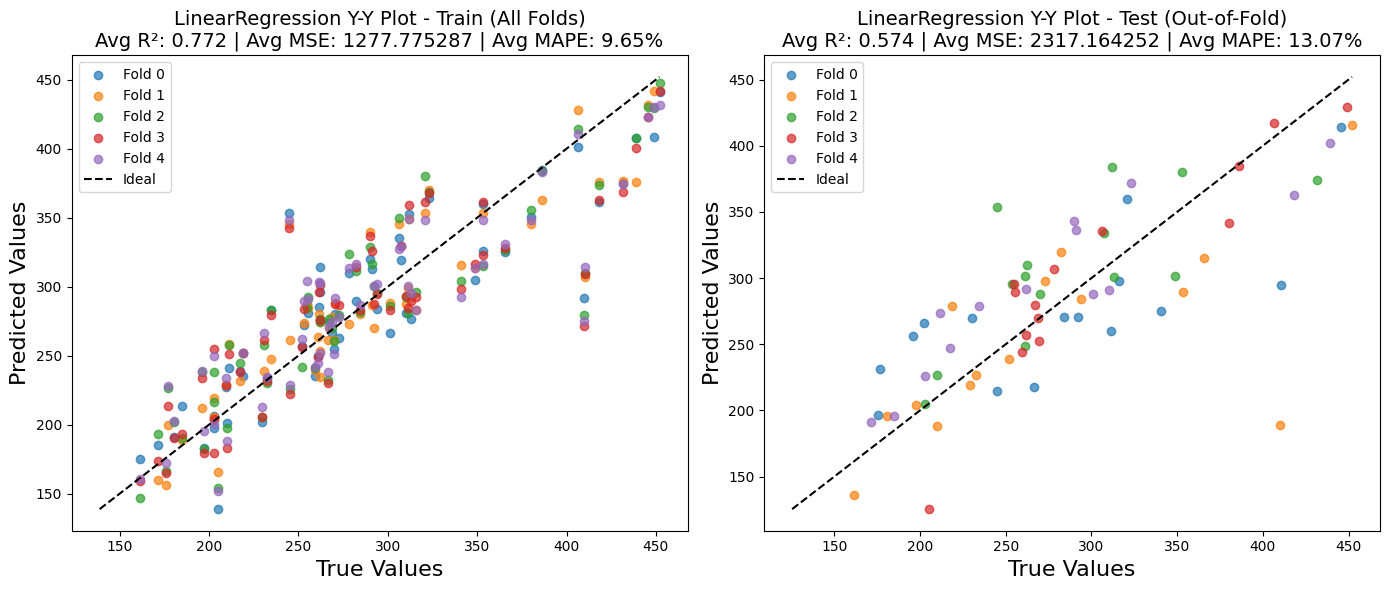

[I 2025-11-07 18:26:51,505] A new study created in memory with name: no-name-6579fc58-eb4e-4346-a253-3da2e80ef20b



--- Starting Workflow for: BayesianRidge ---

--- BayesianRidge - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'YS__MPa_Results\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-07 18:26:57,461] Trial 10 finished with values: [0.3893766572646374, 0.5214332200809397] and parameters: {'max_iter': 455, 'alpha_1': 1.1817791035030754e-07, 'alpha_2': 1.0910439833950487e-07, 'lambda_1': 2.6678977745438506e-07, 'lambda_2': 1.5099927569439613e-07}.
[I 2025-11-07 18:26:57,507] Trial 5 finished with values: [0.3893770478636186, 0.5214327934939573] and parameters: {'max_iter': 156, 'alpha_1': 2.208423339060884e-06, 'alpha_2': 2.0041277296869867e-07, 'lambda_1': 1.9404112116296009e-07, 'lambda_2': 8.439622786996417e-06}.
[I 2025-11-07 18:26:57,510] Trial 3 finished with values: [0.3893770478636186, 0.5214327934939573] and parameters: {'max_iter': 436, 'alpha_1': 3.2727952819104367e-06, 'alpha_2': 3.961109961985192e-06, 'lambda_1': 1.6705608274250285e-07, 'lambda_2': 6.970304321508096e-06}.
[I 2025-11-07 18:26:57,522] Trial 4 finished with values: [0.3893770478636186, 0.5214327934939573] and parameters: {'max_iter': 434, 'alpha_1': 3.1538538589877926e-06, 'alpha_

c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:281: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:288: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:297: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:306: ExperimentalWar

Optuna plots for BayesianRidge saved as PNGs in 'YS__MPa_Results\plots' directory.

--- BayesianRidge - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- BayesianRidge - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
BayesianRidge_x_scaler_fold_0.pkl and BayesianRidge_y_scaler_fold_0.pkl saved in 'YS__MPa_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.002 seconds.
Saving model for BayesianRidge from Fold 0...
Best model (Fold 0) saved to: YS__MPa_Results\models\BayesianRidge_best_model_fold_0.pkl

--- BayesianRidge - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
BayesianRidge_x_scaler_fold_1.pkl and BayesianRidge_y_scaler_fold_1.pkl saved in 'YS__MPa_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 0.000 seconds.
Saving model for BayesianRidge from Fold 1...
Best model (Fold 1) saved to: YS__MPa_Results\mo

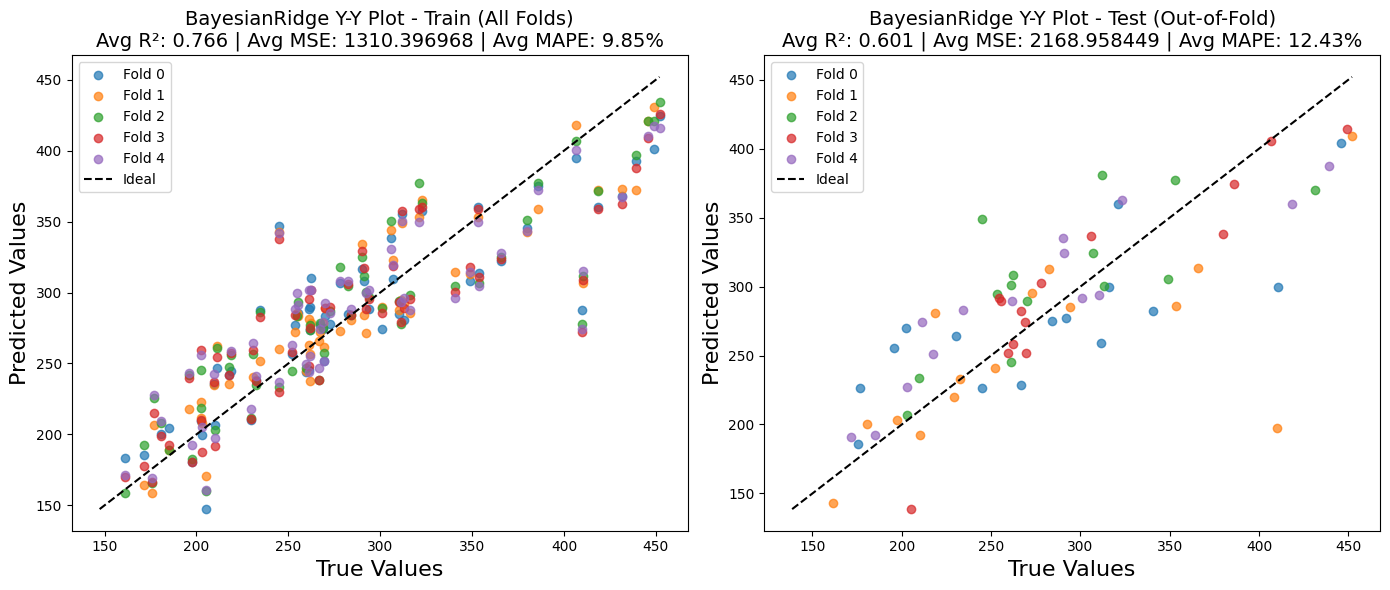

[I 2025-11-07 18:27:03,535] A new study created in memory with name: no-name-8daf66b2-7350-46bf-aa06-a534af8948db



--- Starting Workflow for: SVR ---

--- SVR - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'YS__MPa_Results\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-07 18:27:03,701] Trial 1 finished with values: [0.43667751961844675, 0.4834220259163587] and parameters: {'C': 0.14504008846555458, 'gamma': 0.4929673455141964, 'epsilon': 0.09879758652295176}.
[I 2025-11-07 18:27:03,701] Trial 0 finished with values: [0.43667751961844675, 0.4834220259163587] and parameters: {'C': 1505.4985776577741, 'gamma': 0.00032878709041786, 'epsilon': 0.004013019292404505}.
[I 2025-11-07 18:27:03,748] Trial 3 finished with values: [0.459925969293017, 0.4444249953016085] and parameters: {'C': 91.76722471673945, 'gamma': 0.00011735412597595951, 'epsilon': 0.0032986279221027246}.
[I 2025-11-07 18:27:03,780] Trial 18 finished with values: [0.46135514420202633, 0.4303777142402507] and parameters: {'C': 28.660958097088557, 'gamma': 0.00666246014536869, 'epsilon': 0.030062857315439798}.
[I 2025-11-07 18:27:03,780] Trial 14 finished with values: [0.9513704348930336, -0.17462354403559951] and parameters: {'C': 45.64751126866688, 'gamma': 0.06584948757689082, 'e

c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:281: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:288: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:297: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:306: ExperimentalWar

Optuna plots for SVR saved as PNGs in 'YS__MPa_Results\plots' directory.

--- SVR - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- SVR - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
SVR_x_scaler_fold_0.pkl and SVR_y_scaler_fold_0.pkl saved in 'YS__MPa_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.003 seconds.
Saving model for SVR from Fold 0...
Best model (Fold 0) saved to: YS__MPa_Results\models\SVR_best_model_fold_0.pkl

--- SVR - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
SVR_x_scaler_fold_1.pkl and SVR_y_scaler_fold_1.pkl saved in 'YS__MPa_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 0.001 seconds.
Saving model for SVR from Fold 1...
Best model (Fold 1) saved to: YS__MPa_Results\models\SVR_best_model_fold_1.pkl

--- SVR - Evaluation Fold 3/5 ---
Fitting scalers on Fold 3 training data...
S

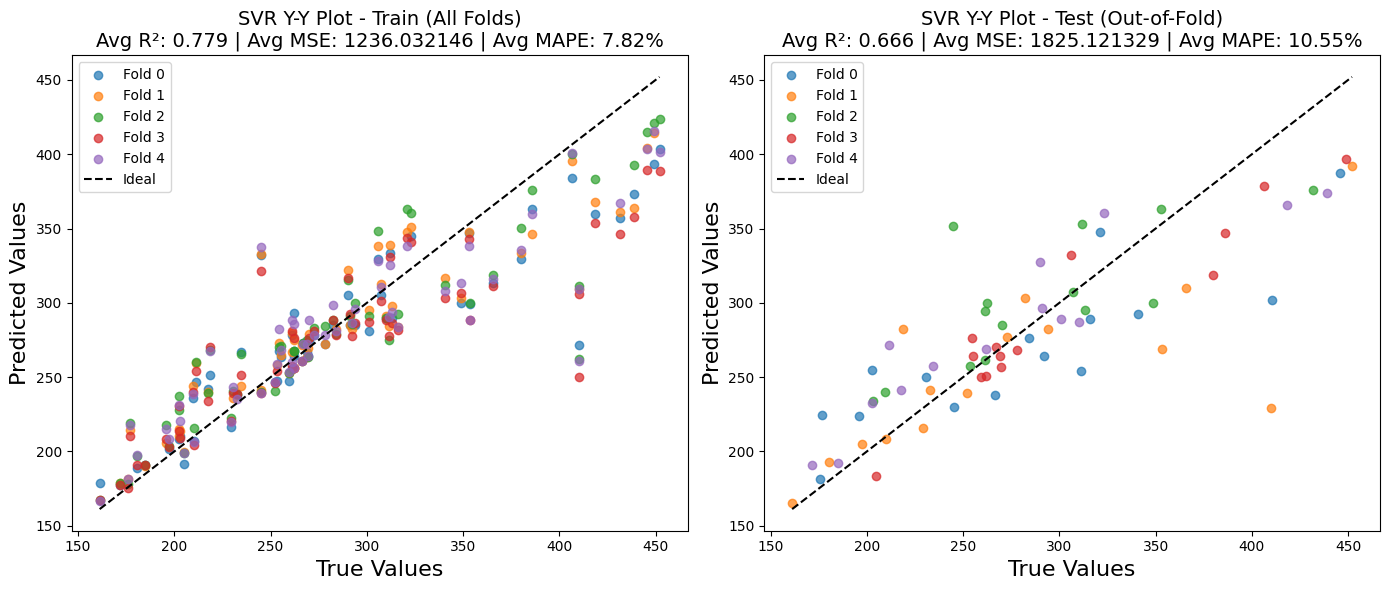

[I 2025-11-07 18:27:10,416] A new study created in memory with name: no-name-8abc75b8-b9fa-475d-ba67-66d3c08073d1



--- Starting Workflow for: DecisionTree ---

--- DecisionTree - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'YS__MPa_Results\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-07 18:27:10,669] Trial 0 finished with values: [0.6868389472105497, 0.1961052324927201] and parameters: {'max_depth': 37, 'min_samples_split': 11, 'min_samples_leaf': 7}.
[I 2025-11-07 18:27:10,716] Trial 3 finished with values: [0.7729202774331763, 0.10299649360517724] and parameters: {'max_depth': 28, 'min_samples_split': 8, 'min_samples_leaf': 20}.
[I 2025-11-07 18:27:10,720] Trial 1 finished with values: [0.5827979436201082, 0.294943016814206] and parameters: {'max_depth': 29, 'min_samples_split': 4, 'min_samples_leaf': 9}.
[I 2025-11-07 18:27:10,764] Trial 13 finished with values: [0.6779706910727162, 0.19210735996432712] and parameters: {'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 11}.
[I 2025-11-07 18:27:10,768] Trial 7 finished with values: [0.6779706910727162, 0.19210735996432712] and parameters: {'max_depth': 16, 'min_samples_split': 8, 'min_samples_leaf': 17}.
[I 2025-11-07 18:27:10,768] Trial 18 finished with values: [0.905206200051896, -0.214834

c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:281: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:288: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:297: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:306: ExperimentalWar

Optuna plots for DecisionTree saved as PNGs in 'YS__MPa_Results\plots' directory.

--- DecisionTree - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- DecisionTree - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
DecisionTree_x_scaler_fold_0.pkl and DecisionTree_y_scaler_fold_0.pkl saved in 'YS__MPa_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.000 seconds.
Saving model for DecisionTree from Fold 0...
Best model (Fold 0) saved to: YS__MPa_Results\models\DecisionTree_best_model_fold_0.pkl

--- DecisionTree - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
DecisionTree_x_scaler_fold_1.pkl and DecisionTree_y_scaler_fold_1.pkl saved in 'YS__MPa_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 0.000 seconds.
Saving model for DecisionTree from Fold 1...
Best model (Fold 1) saved to: YS__MPa_Results\models\Decisi

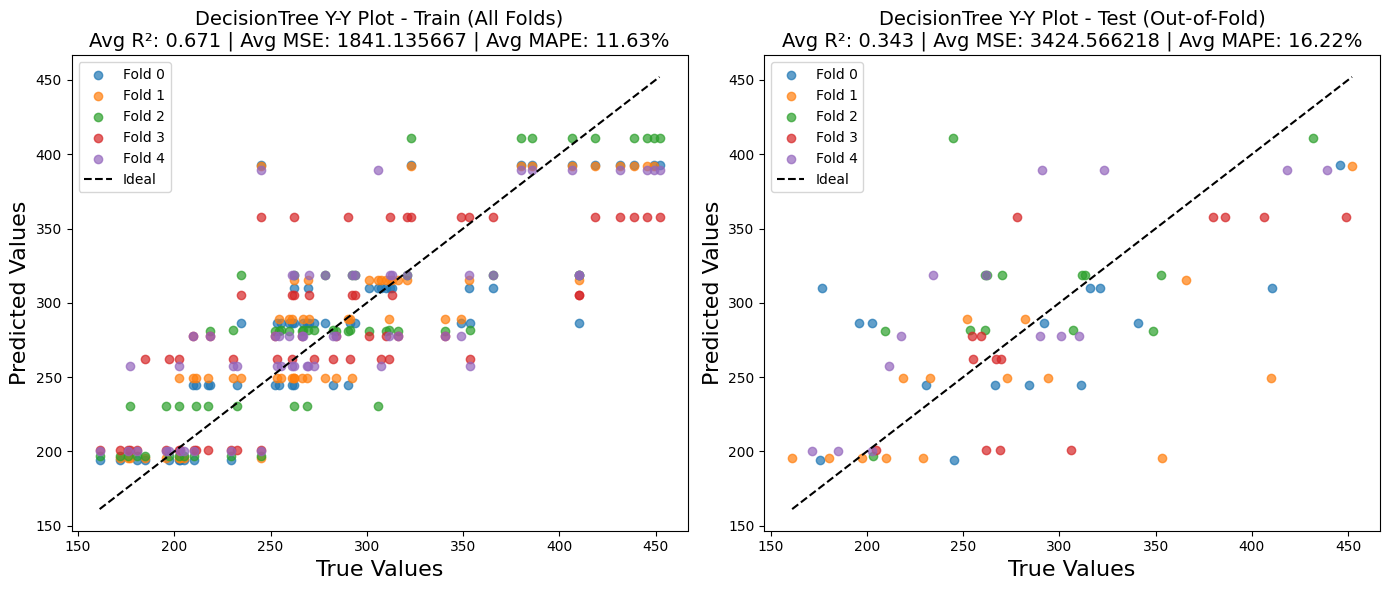

[I 2025-11-07 18:27:16,741] A new study created in memory with name: no-name-2a55035f-5398-4dba-a8d4-23d53415b423



--- Starting Workflow for: RandomForest ---

--- RandomForest - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'YS__MPa_Results\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-07 18:27:17,432] Trial 1 finished with values: [0.5040261930041103, 0.40660636265196093] and parameters: {'n_estimators': 194, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 6}.
[I 2025-11-07 18:27:17,729] Trial 3 finished with values: [0.6336921368193866, 0.22493693654857708] and parameters: {'n_estimators': 141, 'max_depth': 44, 'min_samples_split': 8, 'min_samples_leaf': 5}.
[I 2025-11-07 18:27:18,274] Trial 0 finished with values: [0.5538492808597412, 0.31203761490927284] and parameters: {'n_estimators': 91, 'max_depth': 32, 'min_samples_split': 9, 'min_samples_leaf': 2}.
[I 2025-11-07 18:27:18,307] Trial 8 finished with values: [0.5277592201957253, 0.37355160776623497] and parameters: {'n_estimators': 177, 'max_depth': 21, 'min_samples_split': 4, 'min_samples_leaf': 7}.
[I 2025-11-07 18:27:18,390] Trial 2 finished with values: [0.4224700570005905, 0.48701271841235216] and parameters: {'n_estimators': 50, 'max_depth': 33, 'min_samples_split': 17, 'min_sample

c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:281: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:288: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:297: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:306: ExperimentalWar

Optuna plots for RandomForest saved as PNGs in 'YS__MPa_Results\plots' directory.

--- RandomForest - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- RandomForest - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
RandomForest_x_scaler_fold_0.pkl and RandomForest_y_scaler_fold_0.pkl saved in 'YS__MPa_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.218 seconds.
Saving model for RandomForest from Fold 0...
Best model (Fold 0) saved to: YS__MPa_Results\models\RandomForest_best_model_fold_0.pkl

--- RandomForest - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
RandomForest_x_scaler_fold_1.pkl and RandomForest_y_scaler_fold_1.pkl saved in 'YS__MPa_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 0.201 seconds.
Saving model for RandomForest from Fold 1...
Best model (Fold 1) saved to: YS__MPa_Results\models\Random

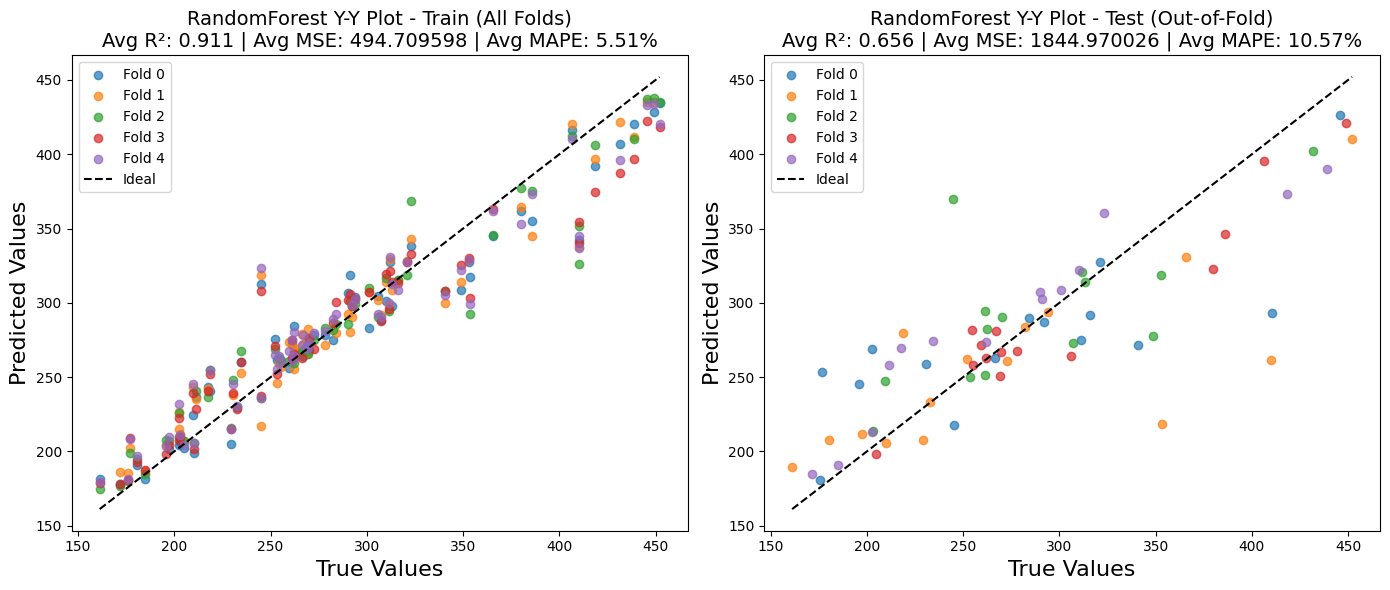

[I 2025-11-07 18:27:33,020] A new study created in memory with name: no-name-45130ebf-aef4-4756-a8a4-6e36de44e4b8



--- Starting Workflow for: XGBoost ---

--- XGBoost - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'YS__MPa_Results\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-07 18:27:34,305] Trial 0 finished with values: [0.3757152739516232, 0.5545042855914806] and parameters: {'n_estimators': 145, 'learning_rate': 0.01506221646439925, 'max_depth': 8, 'subsample': 0.6509999087238318, 'colsample_bytree': 0.649110563799919}.
[I 2025-11-07 18:27:34,313] Trial 1 finished with values: [0.3746101940377664, 0.5432006979735218] and parameters: {'n_estimators': 158, 'learning_rate': 0.0227654945497723, 'max_depth': 9, 'subsample': 0.9855519861715669, 'colsample_bytree': 0.7543947925733633}.
[I 2025-11-07 18:27:34,382] Trial 5 finished with values: [0.323040109939256, 0.5582640633553546] and parameters: {'n_estimators': 191, 'learning_rate': 0.09451053794154325, 'max_depth': 8, 'subsample': 0.8236147387650269, 'colsample_bytree': 0.6064711344844465}.
[I 2025-11-07 18:27:34,398] Trial 3 finished with values: [0.41630120687401206, 0.44547351745758085] and parameters: {'n_estimators': 197, 'learning_rate': 0.1712702399599624, 'max_depth': 6, 'subsample': 0.7

c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:281: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:288: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:297: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:306: ExperimentalWar

Optuna plots for XGBoost saved as PNGs in 'YS__MPa_Results\plots' directory.

--- XGBoost - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- XGBoost - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
XGBoost_x_scaler_fold_0.pkl and XGBoost_y_scaler_fold_0.pkl saved in 'YS__MPa_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.206 seconds.
Saving model for XGBoost from Fold 0...
Best model (Fold 0) saved to: YS__MPa_Results\models\XGBoost_best_model_fold_0.pkl

--- XGBoost - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
XGBoost_x_scaler_fold_1.pkl and XGBoost_y_scaler_fold_1.pkl saved in 'YS__MPa_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 0.041 seconds.
Saving model for XGBoost from Fold 1...
Best model (Fold 1) saved to: YS__MPa_Results\models\XGBoost_best_model_fold_1.pkl

--- XGBoost - Evaluation Fold 

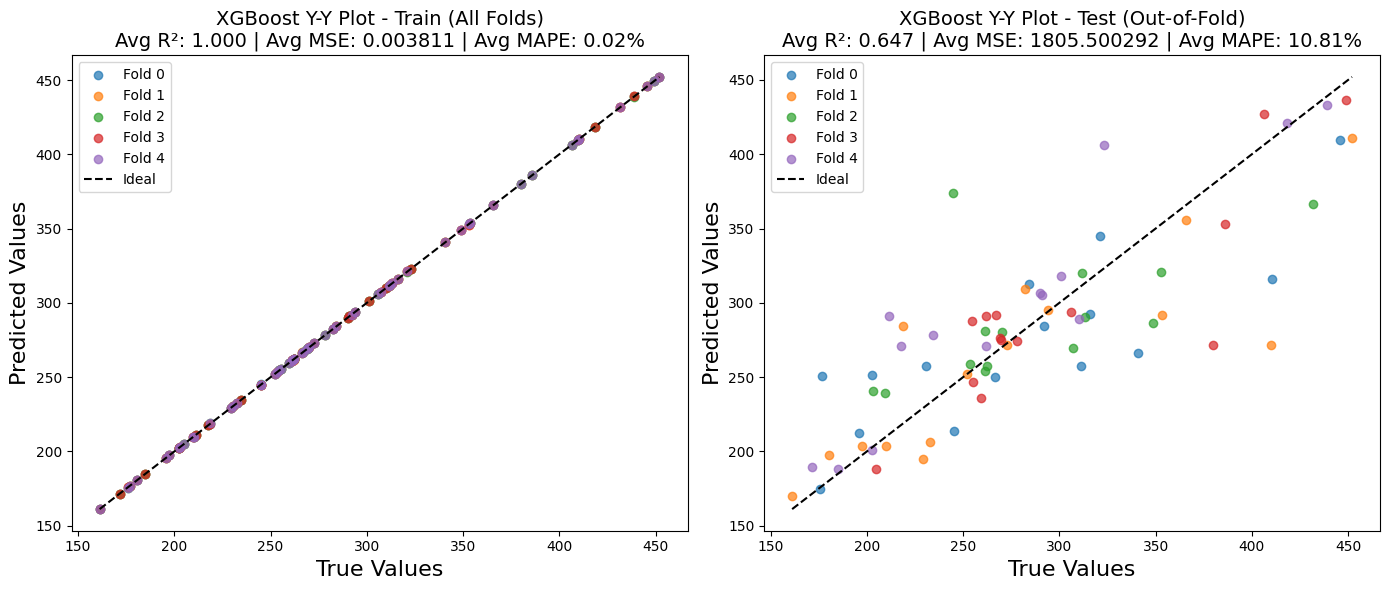

[I 2025-11-07 18:27:42,373] A new study created in memory with name: no-name-6b70924a-4d20-40c8-8718-587ba967ed34



--- Starting Workflow for: GPR ---

--- GPR - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'YS__MPa_Results\models'.
Using n_jobs=1 for GaussianProcessRegressor to manage high memory usage.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-07 18:27:42,614] Trial 0 finished with values: [0.6331925535510831, 0.16285705837760972] and parameters: {'kernel': 'RationalQuadratic', 'alpha': 1.2363474706991415e-05}.
[I 2025-11-07 18:27:42,725] Trial 1 finished with values: [0.4606233489860544, 0.42028063410681116] and parameters: {'kernel': 'Matern_nu_1.5', 'alpha': 0.018516116466572294}.
[I 2025-11-07 18:27:42,836] Trial 2 finished with values: [0.8642710849605264, -0.14044052675425708] and parameters: {'kernel': 'RBF_default', 'alpha': 1.711967411595788e-08}.
[I 2025-11-07 18:27:42,940] Trial 3 finished with values: [0.7845985951313554, -0.048108956740577156] and parameters: {'kernel': 'Matern_nu_0.5', 'alpha': 5.504924691683327e-08}.
[I 2025-11-07 18:27:43,137] Trial 4 finished with values: [0.6331982934790272, 0.16284671104691534] and parameters: {'kernel': 'RationalQuadratic', 'alpha': 2.6191266616692883e-10}.
[I 2025-11-07 18:27:43,327] Trial 5 finished with values: [0.6331982547316305, 0.16284678813102882] and p

c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:281: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:288: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:297: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:306: ExperimentalWar

Optuna plots for GPR saved as PNGs in 'YS__MPa_Results\plots' directory.

--- GPR - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- GPR - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
GPR_x_scaler_fold_0.pkl and GPR_y_scaler_fold_0.pkl saved in 'YS__MPa_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.064 seconds.
Saving model for GPR from Fold 0...
Best model (Fold 0) saved to: YS__MPa_Results\models\GPR_best_model_fold_0.pkl

--- GPR - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
GPR_x_scaler_fold_1.pkl and GPR_y_scaler_fold_1.pkl saved in 'YS__MPa_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 0.098 seconds.
Saving model for GPR from Fold 1...
Best model (Fold 1) saved to: YS__MPa_Results\models\GPR_best_model_fold_1.pkl

--- GPR - Evaluation Fold 3/5 ---
Fitting scalers on Fold 3 training data...
G

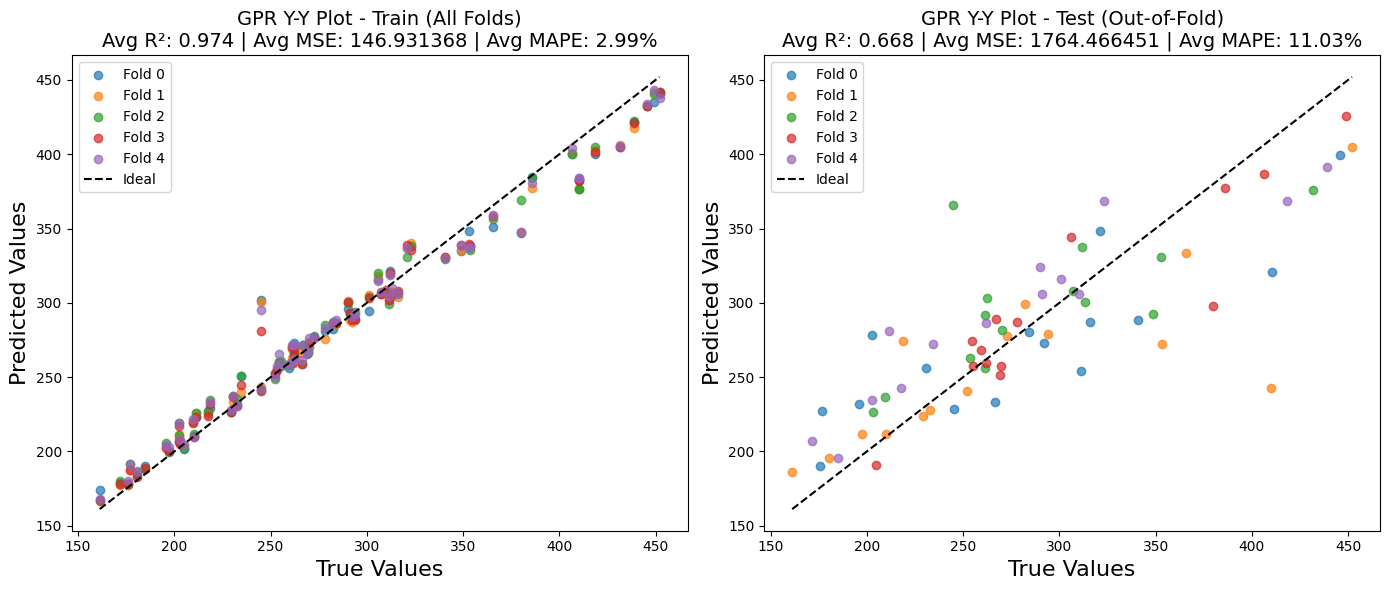

[I 2025-11-07 18:27:58,390] A new study created in memory with name: no-name-c15ebcae-7b0f-43be-ac4c-ecfc2a8c6f0e



--- Starting Workflow for: NNR ---

--- NNR - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'YS__MPa_Results\models'.
Using n_jobs=1 for Neural Network to ensure GPU stability.


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 [==============================] - 0s 46ms/step
[I 2025-11-07 18:28:16,133] Trial 0 finished with values: [0.3568792691759525, 0.6065591194992941] and parameters: {'hidden_layers': 3, 'units': 58, 'activation': 'selu', 'learning_rate': 0.001647925368334971}.
1/1 [==============================] - 0s 47ms/step
[I 2025-11-07 18:28:30,337] Trial 1 finished with values: [0.5145506632471141, 0.44417540195267174] and parameters: {'hidden_layers': 4, 'units': 64, 'activation': 'tanh', 'learning_rate': 0.003303414025808976}.
1/1 [==============================] - 0s 60ms/step
[I 2025-11-07 18:28:44,479] Trial 2 finished with values: [0.33856332666156375, 0.6469130974879146] and parameters: {'hidden_layers': 4, 'units': 87, 'activation': 'tanh', 'learning_rate': 8.832614716583228e-05}.
1/1 [==============================] - 0s 48ms/step
[I 2025-11-07 18:28:55,290] Trial 3 finished with values: [0.5986858884270397, 0.3698618110593869] and parameters: {'hidden_layers': 1, 'units': 55, 'activa

c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:281: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:288: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:297: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:306: ExperimentalWar

Optuna plots for NNR saved as PNGs in 'YS__MPa_Results\plots' directory.

--- NNR - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- NNR - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
NNR_x_scaler_fold_0.pkl and NNR_y_scaler_fold_0.pkl saved in 'YS__MPa_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 2.964 seconds.
1/1 [==============================] - 0s 11ms/step
Saving model for NNR from Fold 0...
Best model (Fold 0) saved to: YS__MPa_Results\models\NNR_best_model_fold_0.keras

--- NNR - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
NNR_x_scaler_fold_1.pkl and NNR_y_scaler_fold_1.pkl saved in 'YS__MPa_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 2.693 seconds.
1/1 [==============================] - 0s 17ms/step
Saving model for NNR from Fold 1...
Best model (Fold 1) saved to: YS__MPa_Results\models

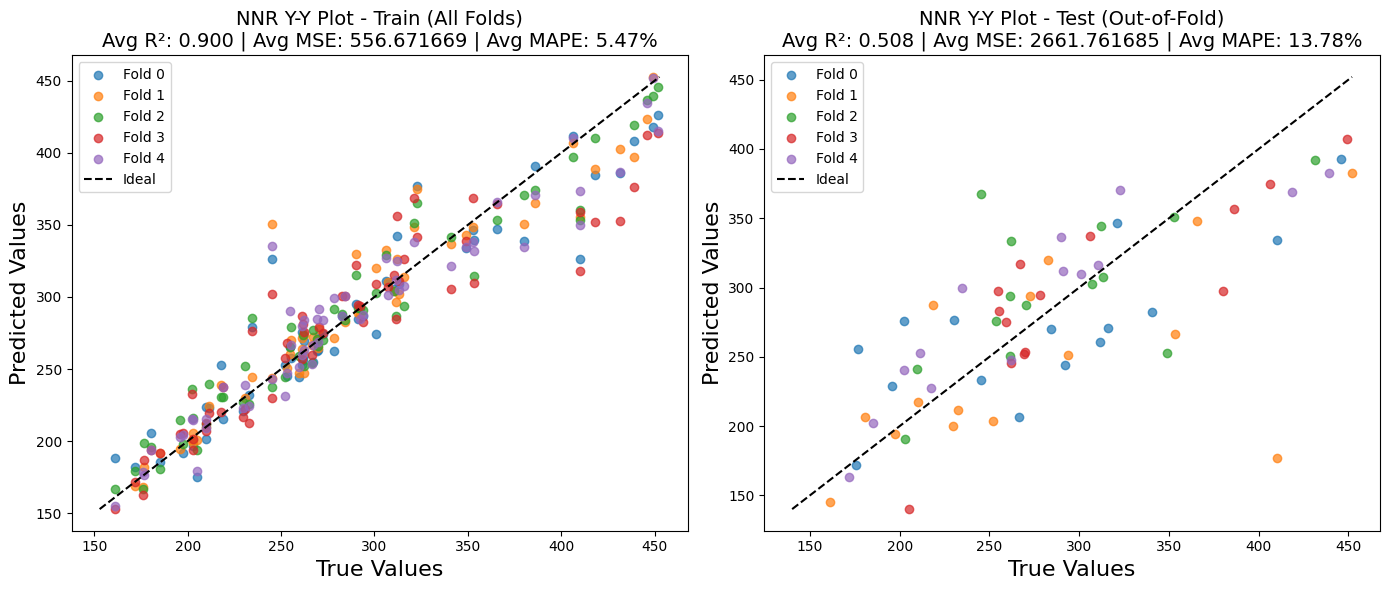


--- Workflow Complete ---
Final 5-fold CV results summary saved to YS__MPa_Results\results_5_fold_CV.csv

============================== Completed Workflow for: YS (MPa) ==============================


============================== Processing Target: Hardness, HV ==============================
All outputs will be saved to: 'Hardness_HV_Results' folder.
Initializing Pre-Optimization CV workflow for target: 'Hardness_HV_Results'...
Setting up directories...

--- Starting Workflow for: LinearRegression ---

--- LinearRegression - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'Hardness_HV_Results\models'.
No hyperparameters defined. Returning default settings.

--- LinearRegression - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- LinearRegression - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
LinearRegression_x_scaler_fold_0.pkl and LinearRegression_y_scaler_fold_0.pkl saved in 'Hardness_HV_Results\mode

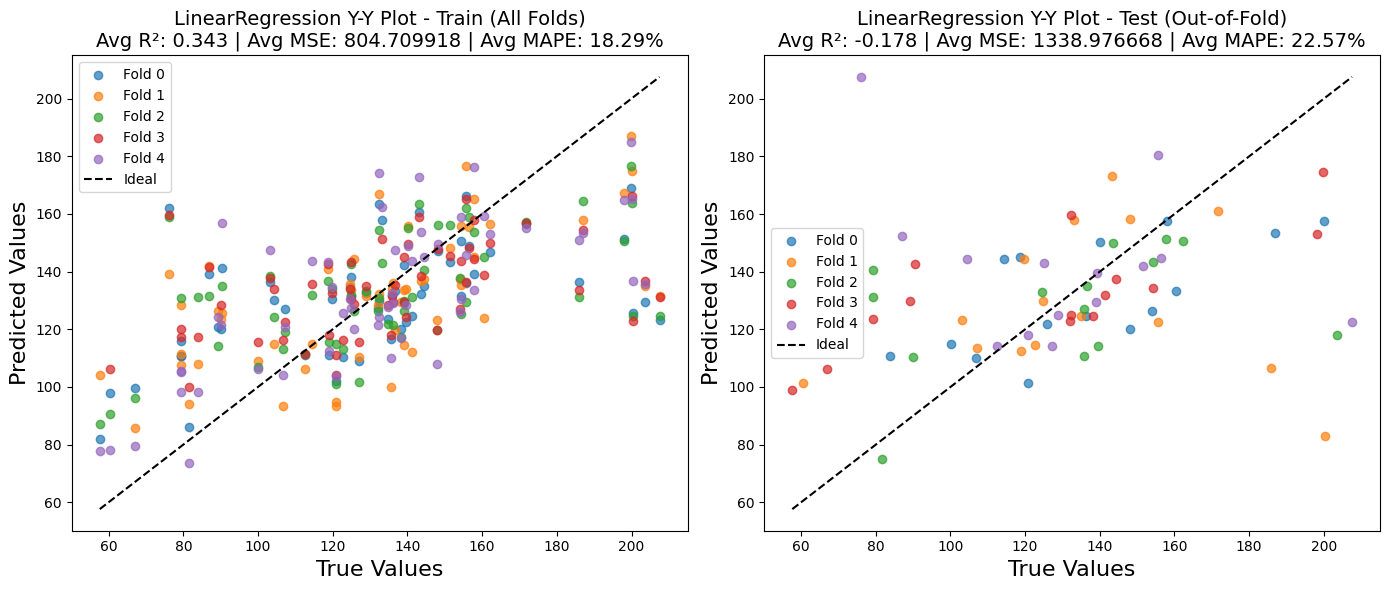

[I 2025-11-07 18:50:02,552] A new study created in memory with name: no-name-4bc50316-e26c-4748-84f8-4006a83d1c32



--- Starting Workflow for: BayesianRidge ---

--- BayesianRidge - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'Hardness_HV_Results\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-07 18:50:08,640] Trial 0 finished with values: [1.7104949149949307, -6.706479219955398] and parameters: {'max_iter': 223, 'alpha_1': 5.42385918227123e-06, 'alpha_2': 4.14307326427946e-06, 'lambda_1': 1.1247679298598493e-07, 'lambda_2': 2.0565881182196594e-07}.
[I 2025-11-07 18:50:08,672] Trial 16 finished with values: [1.7105117981156865, -6.706524438468298] and parameters: {'max_iter': 443, 'alpha_1': 9.92797195260044e-07, 'alpha_2': 3.5946879389252697e-07, 'lambda_1': 7.036740124392495e-07, 'lambda_2': 9.118739856841966e-06}.
[I 2025-11-07 18:50:08,672] Trial 6 finished with values: [1.7105091424941476, -6.706517327272619] and parameters: {'max_iter': 120, 'alpha_1': 2.363012026856037e-06, 'alpha_2': 2.7036963813139468e-06, 'lambda_1': 1.2253917165460942e-07, 'lambda_2': 7.283737674134655e-06}.
[I 2025-11-07 18:50:08,673] Trial 9 finished with values: [1.7105091424941476, -6.706517327272619] and parameters: {'max_iter': 214, 'alpha_1': 3.3271466393613495e-06, 'alpha_2': 9.

c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:281: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:288: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:297: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:306: ExperimentalWar

Optuna plots for BayesianRidge saved as PNGs in 'Hardness_HV_Results\plots' directory.

--- BayesianRidge - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- BayesianRidge - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
BayesianRidge_x_scaler_fold_0.pkl and BayesianRidge_y_scaler_fold_0.pkl saved in 'Hardness_HV_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.000 seconds.
Saving model for BayesianRidge from Fold 0...
Best model (Fold 0) saved to: Hardness_HV_Results\models\BayesianRidge_best_model_fold_0.pkl

--- BayesianRidge - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
BayesianRidge_x_scaler_fold_1.pkl and BayesianRidge_y_scaler_fold_1.pkl saved in 'Hardness_HV_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 0.000 seconds.
Saving model for BayesianRidge from Fold 1...
Best model (Fold 1) saved to: Ha

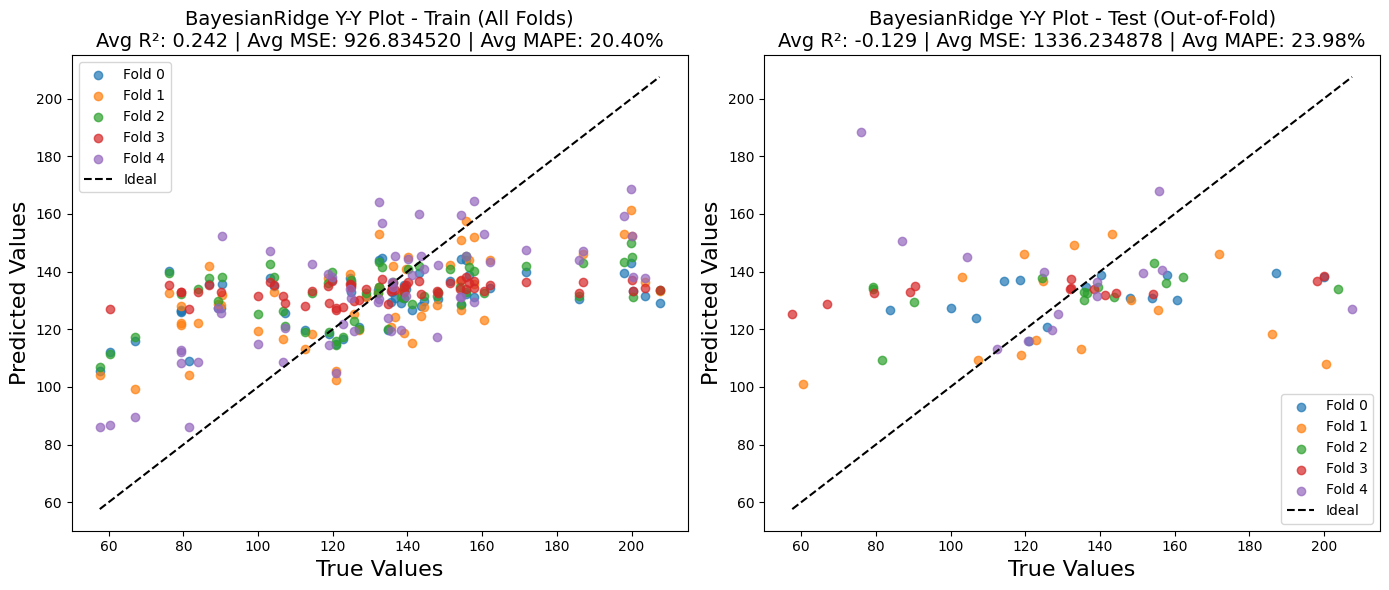

[I 2025-11-07 18:50:15,141] A new study created in memory with name: no-name-b2d0000e-c899-49ab-9980-8ef6dd2af624



--- Starting Workflow for: SVR ---

--- SVR - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'Hardness_HV_Results\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-07 18:50:15,318] Trial 0 finished with values: [1.8130658888025593, -7.002850508789129] and parameters: {'C': 0.14484584387568059, 'gamma': 0.002121710064447037, 'epsilon': 0.0045079495745600695}.
[I 2025-11-07 18:50:15,320] Trial 1 finished with values: [1.8466455947830323, -7.256414425625553] and parameters: {'C': 0.27092283110823856, 'gamma': 0.0010330662736786531, 'epsilon': 0.21131611223386312}.
[I 2025-11-07 18:50:15,369] Trial 4 finished with values: [3.015333632276146, -11.215875038487255] and parameters: {'C': 31.338096229794015, 'gamma': 0.15577621865159733, 'epsilon': 0.03915456272652418}.
[I 2025-11-07 18:50:15,369] Trial 2 finished with values: [1.5262114693763316, -5.760802087119399] and parameters: {'C': 4102.968937378879, 'gamma': 0.004581358134230364, 'epsilon': 0.0034577291914965856}.
[I 2025-11-07 18:50:15,369] Trial 5 finished with values: [1.7478469954104519, -5.82122681180424] and parameters: {'C': 1.5929255502971518, 'gamma': 0.005557444507573366, 'eps

c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:281: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:288: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:297: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:306: ExperimentalWar

Optuna plots for SVR saved as PNGs in 'Hardness_HV_Results\plots' directory.

--- SVR - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- SVR - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
SVR_x_scaler_fold_0.pkl and SVR_y_scaler_fold_0.pkl saved in 'Hardness_HV_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.006 seconds.
Saving model for SVR from Fold 0...
Best model (Fold 0) saved to: Hardness_HV_Results\models\SVR_best_model_fold_0.pkl

--- SVR - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
SVR_x_scaler_fold_1.pkl and SVR_y_scaler_fold_1.pkl saved in 'Hardness_HV_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 0.001 seconds.
Saving model for SVR from Fold 1...
Best model (Fold 1) saved to: Hardness_HV_Results\models\SVR_best_model_fold_1.pkl

--- SVR - Evaluation Fold 3/5 ---
Fitting scalers on Fold 

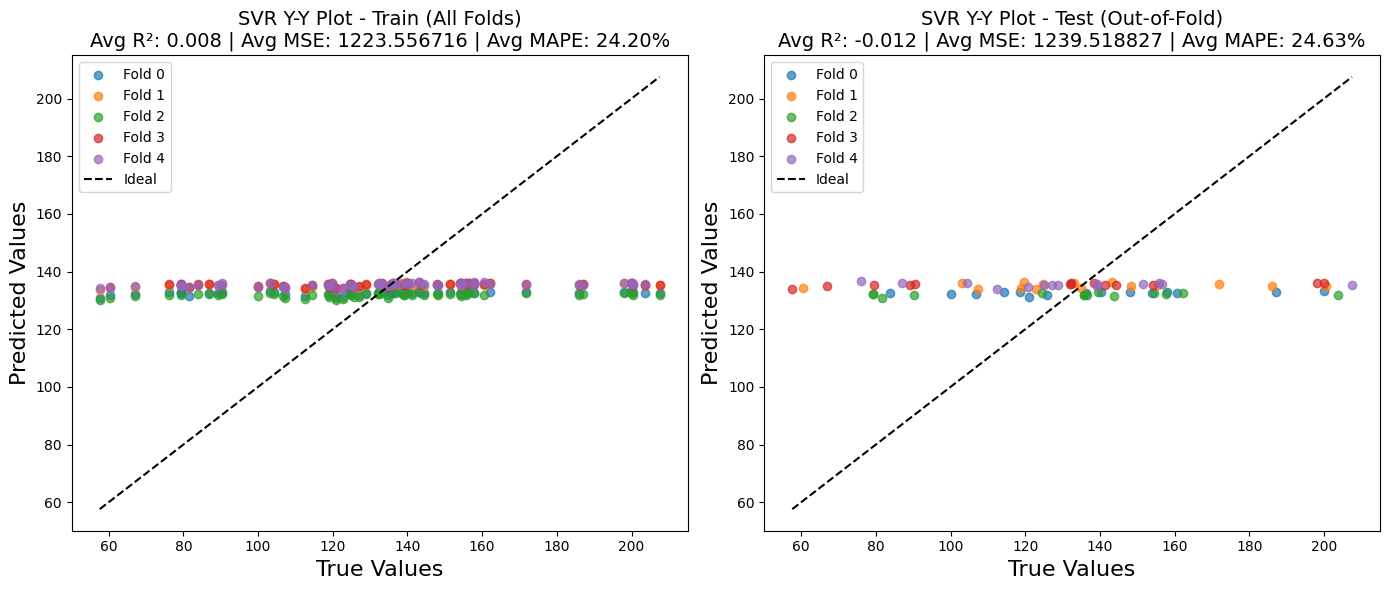

[I 2025-11-07 18:50:21,703] A new study created in memory with name: no-name-8cd35557-93cc-4edc-a0bd-6340434b7688



--- Starting Workflow for: DecisionTree ---

--- DecisionTree - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'Hardness_HV_Results\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-07 18:50:21,963] Trial 0 finished with values: [1.5402423820258377, -4.7196758131910155] and parameters: {'max_depth': 11, 'min_samples_split': 11, 'min_samples_leaf': 2}.
[I 2025-11-07 18:50:21,993] Trial 1 finished with values: [1.5402423820258377, -4.7196758131910155] and parameters: {'max_depth': 17, 'min_samples_split': 17, 'min_samples_leaf': 11}.
[I 2025-11-07 18:50:21,993] Trial 3 finished with values: [1.3251888893247852, -4.475399681465175] and parameters: {'max_depth': 22, 'min_samples_split': 7, 'min_samples_leaf': 3}.
[I 2025-11-07 18:50:21,993] Trial 4 finished with values: [1.557893192491328, -4.91448871930053] and parameters: {'max_depth': 49, 'min_samples_split': 5, 'min_samples_leaf': 14}.
[I 2025-11-07 18:50:21,993] Trial 2 finished with values: [1.5130903651294572, -4.856466061361888] and parameters: {'max_depth': 16, 'min_samples_split': 15, 'min_samples_leaf': 11}.
[I 2025-11-07 18:50:22,057] Trial 10 finished with values: [1.6691141504392302, -5.601621

c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:281: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:288: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:297: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:306: ExperimentalWar

Optuna plots for DecisionTree saved as PNGs in 'Hardness_HV_Results\plots' directory.

--- DecisionTree - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- DecisionTree - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
DecisionTree_x_scaler_fold_0.pkl and DecisionTree_y_scaler_fold_0.pkl saved in 'Hardness_HV_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.002 seconds.
Saving model for DecisionTree from Fold 0...
Best model (Fold 0) saved to: Hardness_HV_Results\models\DecisionTree_best_model_fold_0.pkl

--- DecisionTree - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
DecisionTree_x_scaler_fold_1.pkl and DecisionTree_y_scaler_fold_1.pkl saved in 'Hardness_HV_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 0.000 seconds.
Saving model for DecisionTree from Fold 1...
Best model (Fold 1) saved to: Hardness_HV_R

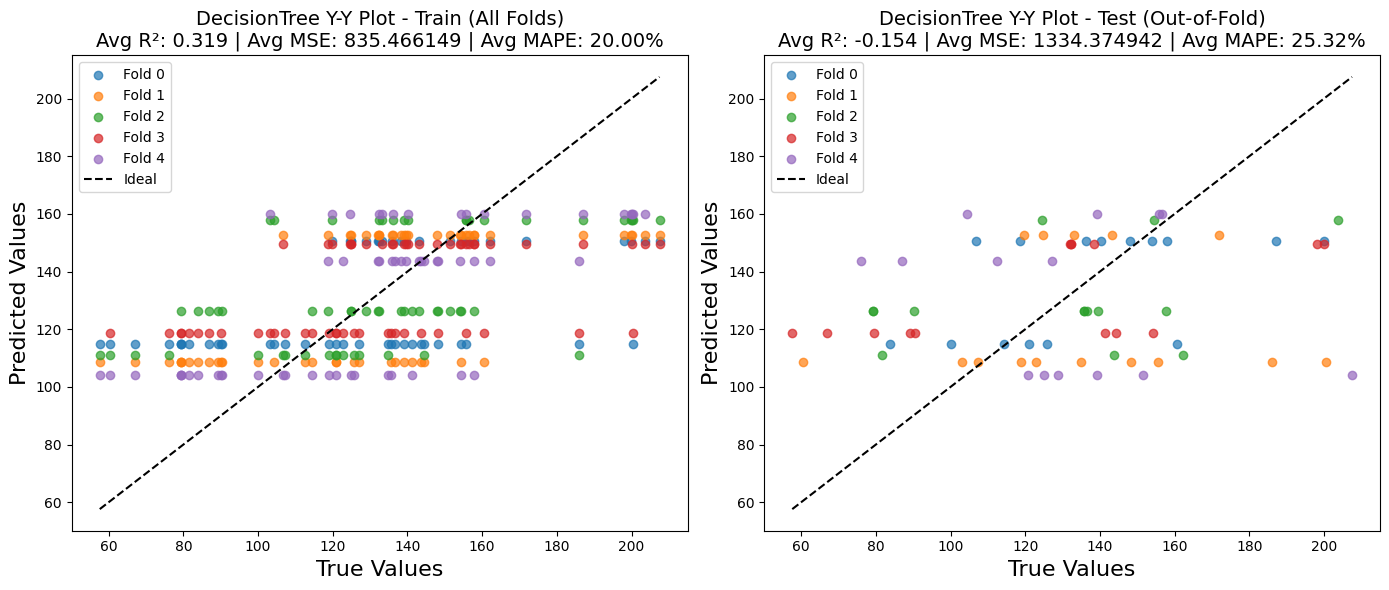

[I 2025-11-07 18:50:29,547] A new study created in memory with name: no-name-5fa7144e-5238-4104-a182-ee0189c2e261



--- Starting Workflow for: RandomForest ---

--- RandomForest - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'Hardness_HV_Results\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-07 18:50:30,093] Trial 0 finished with values: [1.5594050742246157, -6.341431503330512] and parameters: {'n_estimators': 83, 'max_depth': 30, 'min_samples_split': 3, 'min_samples_leaf': 9}.
[I 2025-11-07 18:50:30,378] Trial 2 finished with values: [1.523287314783706, -6.072056265027521] and parameters: {'n_estimators': 89, 'max_depth': 23, 'min_samples_split': 6, 'min_samples_leaf': 10}.
[I 2025-11-07 18:50:30,410] Trial 1 finished with values: [1.5566827950978002, -6.1204500021044925] and parameters: {'n_estimators': 142, 'max_depth': 26, 'min_samples_split': 8, 'min_samples_leaf': 8}.
[I 2025-11-07 18:50:30,696] Trial 3 finished with values: [1.3559537108273851, -4.439618313498635] and parameters: {'n_estimators': 113, 'max_depth': 21, 'min_samples_split': 2, 'min_samples_leaf': 2}.
[I 2025-11-07 18:50:30,870] Trial 4 finished with values: [1.627711518530982, -6.045468278939564] and parameters: {'n_estimators': 121, 'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf

c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:281: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:288: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:297: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:306: ExperimentalWar

Optuna plots for RandomForest saved as PNGs in 'Hardness_HV_Results\plots' directory.

--- RandomForest - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- RandomForest - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
RandomForest_x_scaler_fold_0.pkl and RandomForest_y_scaler_fold_0.pkl saved in 'Hardness_HV_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.191 seconds.
Saving model for RandomForest from Fold 0...
Best model (Fold 0) saved to: Hardness_HV_Results\models\RandomForest_best_model_fold_0.pkl

--- RandomForest - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
RandomForest_x_scaler_fold_1.pkl and RandomForest_y_scaler_fold_1.pkl saved in 'Hardness_HV_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 0.145 seconds.
Saving model for RandomForest from Fold 1...
Best model (Fold 1) saved to: Hardness_HV_R

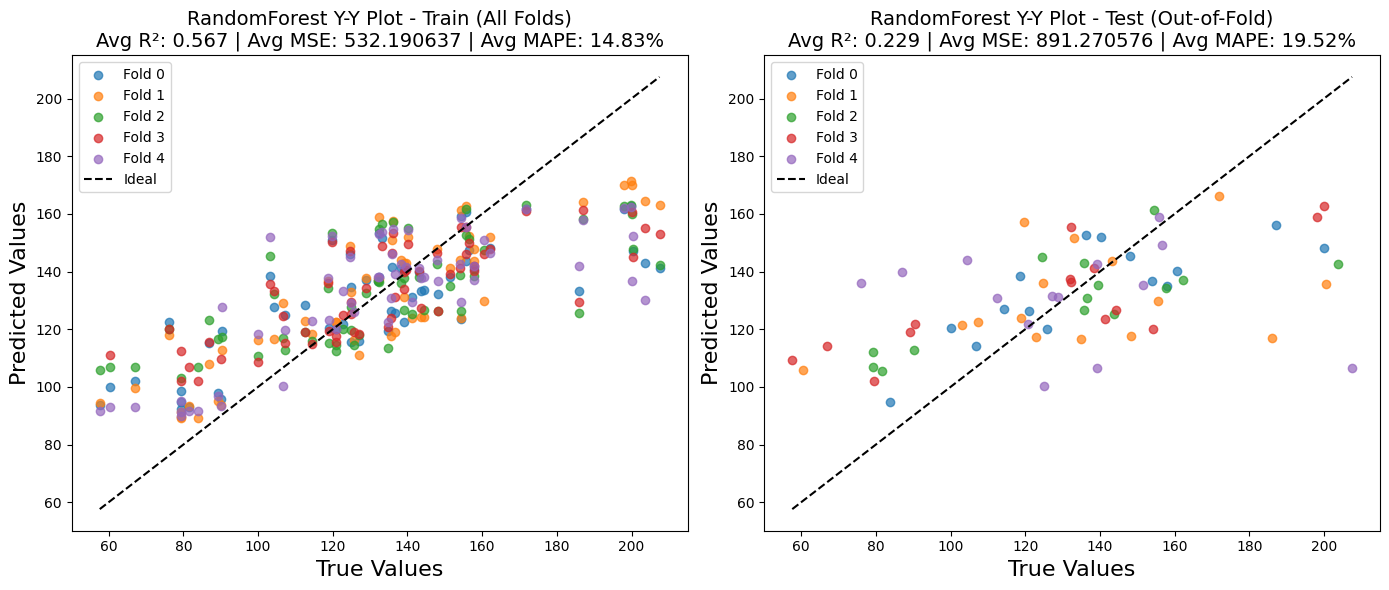

[I 2025-11-07 18:50:46,128] A new study created in memory with name: no-name-6d9f543f-2e28-49f2-90e1-41a4198b60f8



--- Starting Workflow for: XGBoost ---

--- XGBoost - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'Hardness_HV_Results\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-07 18:50:47,498] Trial 1 finished with values: [1.5479358226144018, -6.519357598354259] and parameters: {'n_estimators': 169, 'learning_rate': 0.0330550946081826, 'max_depth': 7, 'subsample': 0.8280452241325105, 'colsample_bytree': 0.6139254910444513}.
[I 2025-11-07 18:50:47,516] Trial 0 finished with values: [1.2902456255735817, -5.171977605425293] and parameters: {'n_estimators': 114, 'learning_rate': 0.04891642199003428, 'max_depth': 3, 'subsample': 0.869571543506233, 'colsample_bytree': 0.8620300324319221}.
[I 2025-11-07 18:50:47,595] Trial 2 finished with values: [1.5076685900632967, -6.356877935867607] and parameters: {'n_estimators': 186, 'learning_rate': 0.14120045255521643, 'max_depth': 10, 'subsample': 0.7829303903201659, 'colsample_bytree': 0.6595774419917767}.
[I 2025-11-07 18:50:47,677] Trial 7 finished with values: [1.4179931765304317, -5.8533450319151115] and parameters: {'n_estimators': 92, 'learning_rate': 0.07670641425202153, 'max_depth': 9, 'subsample': 0.

c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:281: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:288: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:297: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:306: ExperimentalWar

Optuna plots for XGBoost saved as PNGs in 'Hardness_HV_Results\plots' directory.

--- XGBoost - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- XGBoost - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
XGBoost_x_scaler_fold_0.pkl and XGBoost_y_scaler_fold_0.pkl saved in 'Hardness_HV_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.027 seconds.
Saving model for XGBoost from Fold 0...
Best model (Fold 0) saved to: Hardness_HV_Results\models\XGBoost_best_model_fold_0.pkl

--- XGBoost - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
XGBoost_x_scaler_fold_1.pkl and XGBoost_y_scaler_fold_1.pkl saved in 'Hardness_HV_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 0.022 seconds.
Saving model for XGBoost from Fold 1...
Best model (Fold 1) saved to: Hardness_HV_Results\models\XGBoost_best_model_fold_1.pkl

--- XGBoos

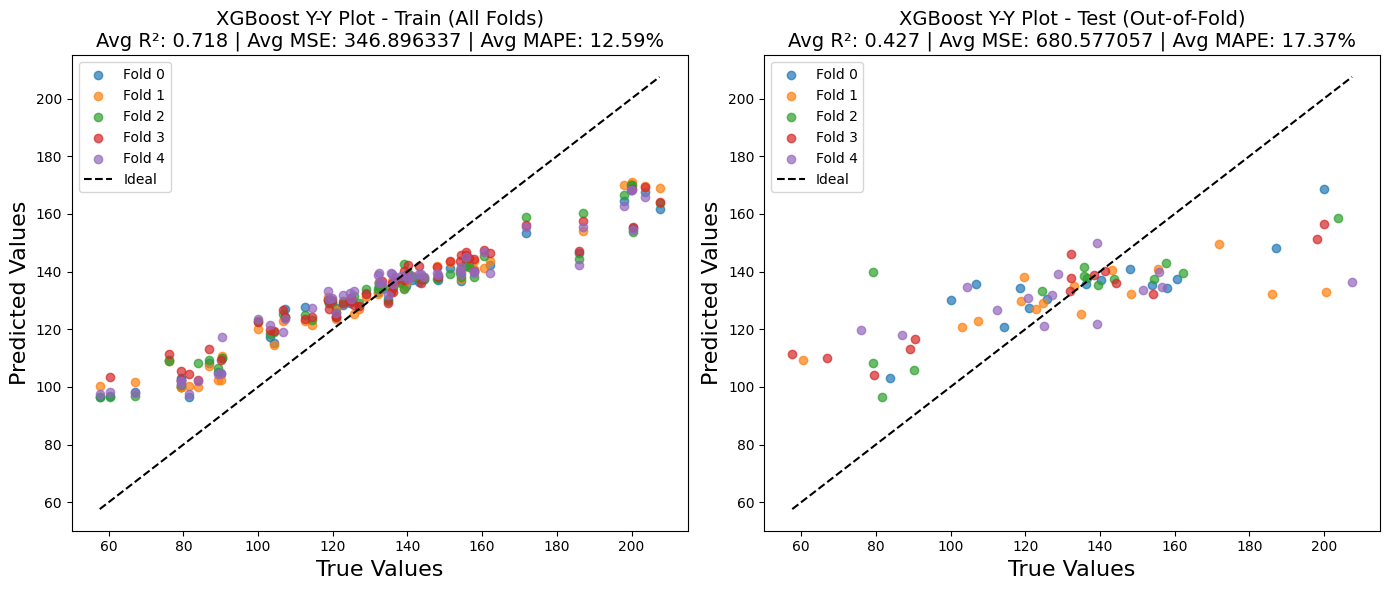

[I 2025-11-07 18:50:55,252] A new study created in memory with name: no-name-1f47a0cc-b8e3-457c-b29e-c3088fd38ead



--- Starting Workflow for: GPR ---

--- GPR - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'Hardness_HV_Results\models'.
Using n_jobs=1 for GaussianProcessRegressor to manage high memory usage.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-07 18:50:55,387] Trial 0 finished with values: [1.4973695046751367, -6.465184202491223] and parameters: {'kernel': 'RBF_default', 'alpha': 0.00019863710205809707}.
[I 2025-11-07 18:50:55,608] Trial 1 finished with values: [1.5781440328365581, -6.546290068066701] and parameters: {'kernel': 'RationalQuadratic', 'alpha': 1.459944378982679e-08}.
[I 2025-11-07 18:50:55,734] Trial 2 finished with values: [1.594168167029062, -6.4626114131524215] and parameters: {'kernel': 'Matern_nu_2.5', 'alpha': 0.003498453318095824}.
[I 2025-11-07 18:50:55,927] Trial 3 finished with values: [1.578144172281219, -6.546290105506006] and parameters: {'kernel': 'RationalQuadratic', 'alpha': 2.4316148710056897e-07}.
[I 2025-11-07 18:50:56,038] Trial 4 finished with values: [1.546806391587729, -6.269327008278777] and parameters: {'kernel': 'Matern_nu_0.5', 'alpha': 1.0252005197790162e-07}.
[I 2025-11-07 18:50:56,275] Trial 5 finished with values: [1.5782557262774348, -6.546367974528269] and parameters:

c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:281: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:288: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:297: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:306: ExperimentalWar

Optuna plots for GPR saved as PNGs in 'Hardness_HV_Results\plots' directory.

--- GPR - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- GPR - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
GPR_x_scaler_fold_0.pkl and GPR_y_scaler_fold_0.pkl saved in 'Hardness_HV_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.062 seconds.
Saving model for GPR from Fold 0...
Best model (Fold 0) saved to: Hardness_HV_Results\models\GPR_best_model_fold_0.pkl

--- GPR - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
GPR_x_scaler_fold_1.pkl and GPR_y_scaler_fold_1.pkl saved in 'Hardness_HV_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 0.132 seconds.
Saving model for GPR from Fold 1...
Best model (Fold 1) saved to: Hardness_HV_Results\models\GPR_best_model_fold_1.pkl

--- GPR - Evaluation Fold 3/5 ---
Fitting scalers on Fold 

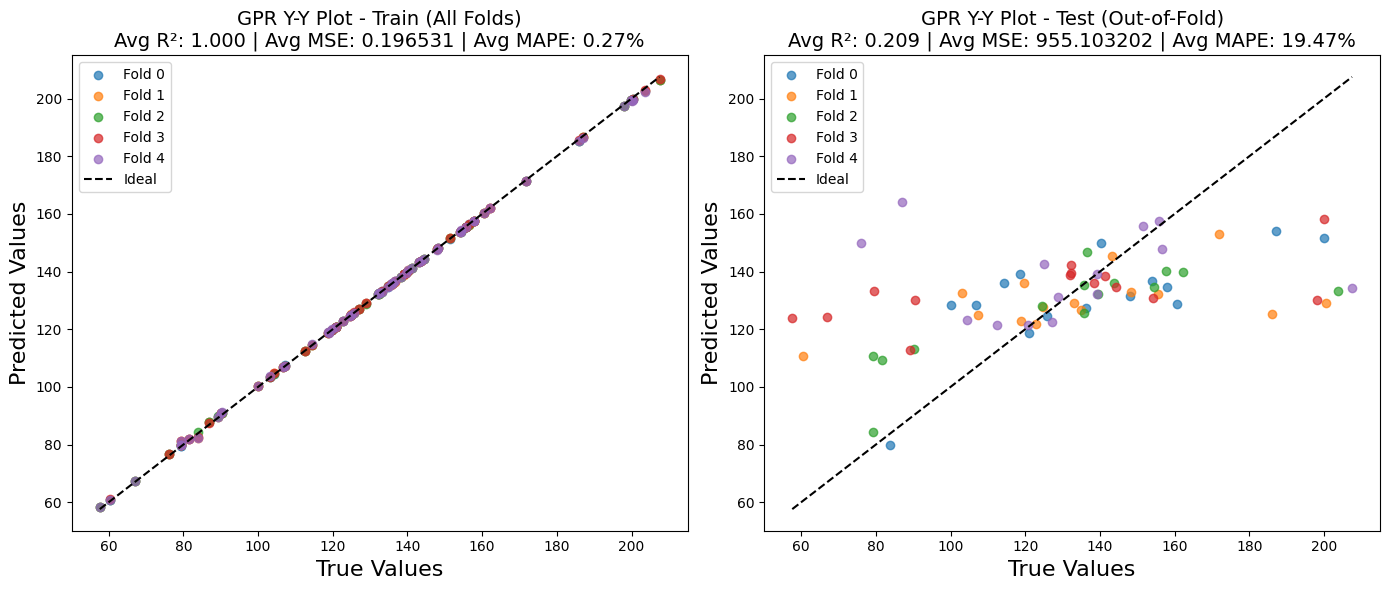

[I 2025-11-07 18:51:13,605] A new study created in memory with name: no-name-a5d818d7-0c4a-41af-b159-a7bbabdba362



--- Starting Workflow for: NNR ---

--- NNR - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'Hardness_HV_Results\models'.
Using n_jobs=1 for Neural Network to ensure GPU stability.


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 [==============================] - 0s 64ms/step
[I 2025-11-07 18:51:27,659] Trial 0 finished with values: [0.8964870785954657, 0.0333137342750214] and parameters: {'hidden_layers': 3, 'units': 101, 'activation': 'tanh', 'learning_rate': 4.923740465965812e-05}.
1/1 [==============================] - 0s 47ms/step
[I 2025-11-07 18:51:39,423] Trial 1 finished with values: [0.957419380891321, -0.04083792490461598] and parameters: {'hidden_layers': 2, 'units': 122, 'activation': 'relu', 'learning_rate': 0.0010909198010596202}.
1/1 [==============================] - 0s 65ms/step
[I 2025-11-07 18:51:53,431] Trial 2 finished with values: [0.9059514477945285, 0.04423059069140234] and parameters: {'hidden_layers': 4, 'units': 53, 'activation': 'tanh', 'learning_rate': 8.017297894128771e-05}.
1/1 [==============================] - 0s 40ms/step
[I 2025-11-07 18:52:04,520] Trial 3 finished with values: [1.1190583783760344, -0.16757582921001538] and parameters: {'hidden_layers': 1, 'units': 120, 

c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:281: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:288: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:297: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\OneDrive\Documents\gitrepo\Grain-size-YS-HV\armote_cv.py:306: ExperimentalWar

Optuna plots for NNR saved as PNGs in 'Hardness_HV_Results\plots' directory.

--- NNR - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- NNR - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
NNR_x_scaler_fold_0.pkl and NNR_y_scaler_fold_0.pkl saved in 'Hardness_HV_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 3.820 seconds.
1/1 [==============================] - 0s 22ms/step
Saving model for NNR from Fold 0...
Best model (Fold 0) saved to: Hardness_HV_Results\models\NNR_best_model_fold_0.keras

--- NNR - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
NNR_x_scaler_fold_1.pkl and NNR_y_scaler_fold_1.pkl saved in 'Hardness_HV_Results\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 3.529 seconds.
1/1 [==============================] - 0s 24ms/step
Saving model for NNR from Fold 1...
Best model (Fold 1) saved to: Hardne

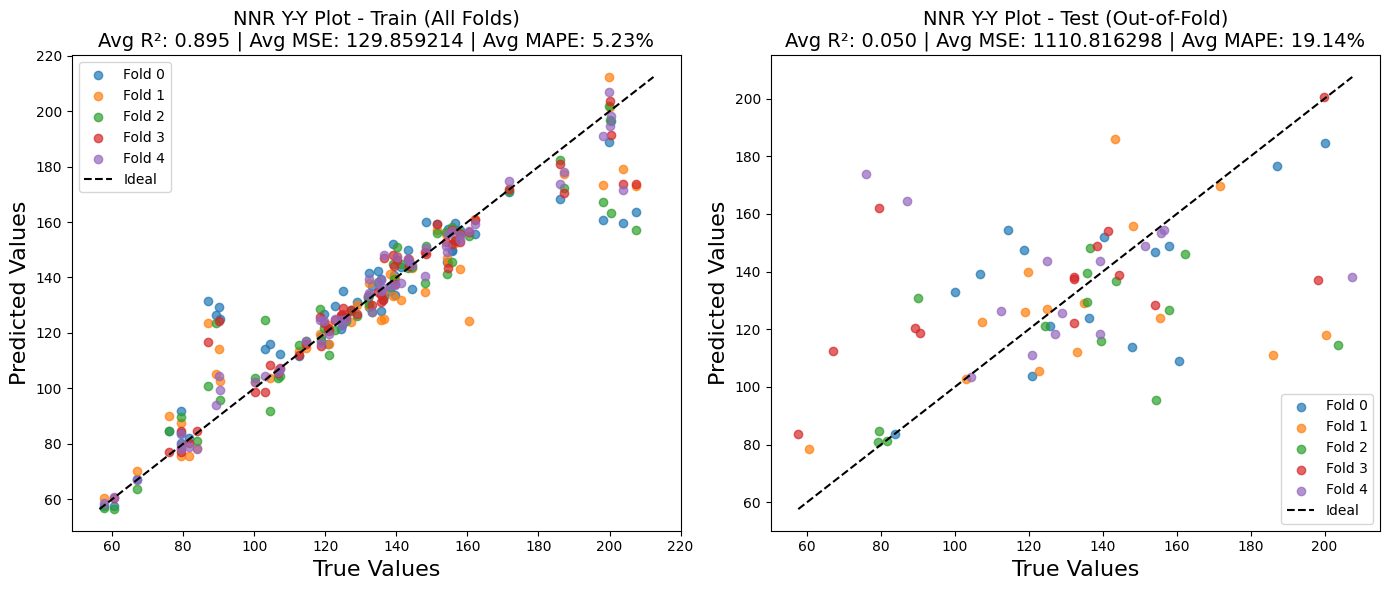


--- Workflow Complete ---
Final 5-fold CV results summary saved to Hardness_HV_Results\results_5_fold_CV.csv

============================== Completed Workflow for: Hardness, HV ==============================


ALL WORKFLOWS COMPLETE.


In [8]:
print("\n" + "="*80)
print("STARTING ALL WORKFLOWS")
print("="*80 + "\n")

for target_name in target_cols:
    print(f"\n{'='*30} Processing Target: {target_name} {'='*30}")
    
    # Select the current target column as a 1D array
    y_current = y_cleaned[target_name].values 
    
    # Sanitize the target name to create a valid folder name
    # "YS (MPa)" -> "YS_MPa_Results"
    # "Hardness, HV" -> "Hardness_HV_Results"
    output_folder_name = target_name.replace(' ', '_').replace('(MPa)', '_MPa')
    output_folder_name = output_folder_name.replace(',', '').replace('/', '_')
    output_folder_name = f"{output_folder_name}_Results"
    
    print(f"All outputs will be saved to: '{output_folder_name}' folder.")
    
    # Run the complete workflow from armote_cv.py
    run_workflow(
        X_cleaned, 
        y_current, 
        models_to_run, 
        param_spaces_to_run, 
        output_name=output_folder_name,
        gpr_kernel_map=my_custom_kernels,
        nn_epochs=100,
        nn_batch_size=8,
    )
    
    print(f"\n{'='*30} Completed Workflow for: {target_name} {'='*30}\n")

print("\n" + "="*80)
print("ALL WORKFLOWS COMPLETE.")
print("="*80)